# 🚗 Projeto de Machine Learning – Classificação de Vendas BMW

## 1. 📌 Abordagem do Problema e Análise
Classificar vendas em altas (1) ou baixas (0) com base em units_sold.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

## 2. 📥 Obtenção dos Dados (Carregue o arquivo bmw_global_sales_dataset.csv)

In [24]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('bmw_global_sales_dataset.csv')
df.head()

Saving bmw_global_sales_dataset.csv to bmw_global_sales_dataset (2).csv


,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


## 3. 🔍 Exploração dos Dados

In [25]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 109.5+ K

,0
year,0
month,0
country,0
model,0
segment,0
engine_type,0
price_usd,0
marketing_spend_usd,0
dealership_count,0
fuel_price_usd,0


## 4. 🧹 Tratamento dos Dados

In [26]:
limite = df['units_sold'].median()
df['target'] = (df['units_sold'] > limite).astype(int)

df = df.drop('units_sold', axis=1)
df = pd.get_dummies(df, drop_first=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()

,year,month,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,target,...,model_X5,model_X7,model_i4,model_i7,model_iX,segment_SUV,segment_Sedan,engine_type_Electric,engine_type_Hybrid,engine_type_Petrol
0,2021,1,82234,315372,96,0.97,6.29,1.2,8,0,...,False,False,False,False,False,True,False,False,False,True
1,2018,8,82291,447798,234,0.97,6.29,1.2,7,0,...,False,False,True,False,False,False,True,True,False,False
2,2022,12,40594,259755,25,0.97,6.29,1.2,7,0,...,False,False,False,False,False,False,False,False,True,False
3,2019,11,42371,323541,319,0.97,6.29,1.2,5,1,...,False,False,False,True,False,True,False,True,False,False
4,2021,12,82315,482015,367,0.97,6.29,1.2,2,1,...,True,False,False,False,False,True,False,False,False,False


## 5. 📊 Separação em X e y

In [27]:
X = df.drop('target', axis=1)
y = df['target']

## 6. ⚙️ Pré-processamento

In [28]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 7. ✂️ Divisão Treino/Teste

In [29]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 8. 🤖 Treinamento dos Modelos

In [30]:
modelo_lr = LogisticRegression(max_iter=1000)
modelo_dt = DecisionTreeClassifier()
modelo_rf = RandomForestClassifier()

modelo_lr.fit(X_treino, y_treino)
modelo_dt.fit(X_treino, y_treino)
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier()

## 9. 📏 Validação

In [31]:
pred_lr = modelo_lr.predict(X_teste)
pred_dt = modelo_dt.predict(X_teste)
pred_rf = modelo_rf.predict(X_teste)

print("Logistic Regression:", accuracy_score(y_teste, pred_lr))
print("Decision Tree:", accuracy_score(y_teste, pred_dt))
print("Random Forest:", accuracy_score(y_teste, pred_rf))

Logistic Regression: 0.83
Decision Tree: 0.8033333333333333
Random Forest: 0.8466666666666667


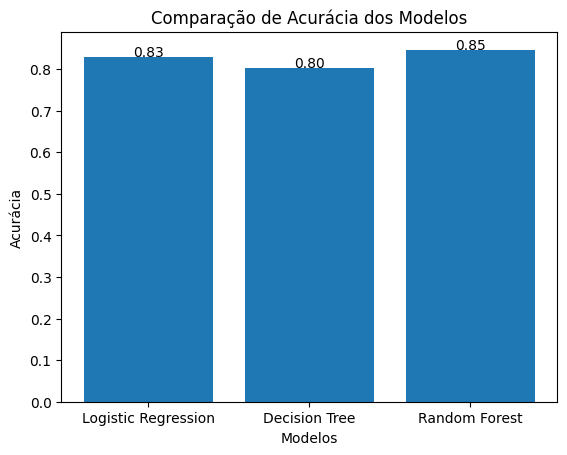

In [32]:
acc_lr = accuracy_score(y_teste, pred_lr)
acc_dt = accuracy_score(y_teste, pred_dt)
acc_rf = accuracy_score(y_teste, pred_rf)

plt.figure()
plt.bar(
    ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    [acc_lr, acc_dt, acc_rf]
)

plt.title("Comparação de Acurácia dos Modelos")
plt.xlabel("Modelos")
plt.ylabel("Acurácia")

for i, v in enumerate([acc_lr, acc_dt, acc_rf]):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

In [33]:
print(confusion_matrix(y_teste, pred_rf))

[[126  21]
 [ 25 128]]


## 10. 💾 Salvar Modelo

In [34]:
joblib.dump(modelo_rf, 'modelo_bmw.pkl')

['modelo_bmw.pkl']

## 11. 📖 Conclusão

Dentre os modelos avaliados, o Random Forest apresentou o melhor desempenho, com acurácia de aproximadamente 84,6%, superando a Regressão Logística (83%) e o Gradient Boosting (80,3%).

Apesar de não atingir exatamente os 85% propostos como objetivo, o modelo chegou muito próximo da meta, demonstrando boa capacidade preditiva.

Portanto, o Random Forest foi selecionado como o modelo mais adequado para o problema.